In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for better looking charts
sns.set_theme(style="whitegrid")

# Load the datasets
musicians_df = pd.read_csv('Dataset/musicians.csv')
clients_df = pd.read_csv('Dataset/clients.csv')
events_df = pd.read_csv('Dataset/events.csv')
bookings_df = pd.read_csv('Dataset/bookings.csv')
reviews_df = pd.read_csv('Dataset/reviews.csv')
print("Data successfully loaded!")
print(f"Total Musicians: {len(musicians_df)}")
print(f"Total Bookings: {len(bookings_df)}")

Data successfully loaded!
Total Musicians: 300
Total Bookings: 200


In [ ]:
# Convert date columns to datetime objects
events_df['Date_Time'] = pd.to_datetime(events_df['Date_Time'])
bookings_df['Date_Time'] = pd.to_datetime(bookings_df['Date_Time'])
reviews_df['Created_At'] = pd.to_datetime(reviews_df['Created_At'])

# Check for missing values in critical columns
print("\nMissing values in Bookings:")
print(bookings_df.isnull().sum())

# Fill missing numerical values with the median
if bookings_df['Price_Charged'].isnull().any():
    bookings_df['Price_Charged'].fillna(bookings_df['Price_Charged'].median(), inplace=True)


Missing values in Bookings:
Booking_ID       0
Musician_ID      0
Client_ID        0
Event_ID         0
Date_Time        0
Duration         0
Price_Charged    0
Rating           0
dtype: int64


In [3]:
# Merge Bookings with Event details
master_df = bookings_df.merge(events_df, on='Event_ID', how='left', suffixes=('_booking', '_event'))

# Merge the result with Musician details
master_df = master_df.merge(musicians_df, on='Musician_ID', how='left')

# Display the first few rows to confirm the merge
master_df.head()

,Booking_ID,Musician_ID,Client_ID_booking,Event_ID,Date_Time_booking,Duration,Price_Charged,Rating,Client_ID_event,City,...,Event_Type,Budget,Musician_Name,Musician_Type,Musician_Contact,Location,Genres,Years_Experience,Base_Price,Social_Links
0,B001,M028,C012,E001,2025-01-11 19:30:00,3,6000,5,C096,London,...,Corporate,15350,London Philharmonic Ensemble,Band,bookings@lpe.co.uk,London,Classical,20,2000,True
1,B002,M004,C002,E002,2025-01-17 21:00:00,2,1600,4,C070,London,...,Corporate,6200,Brass & Copper,Band,hello@brassandcopper.com,Bristol,"Jazz, Soul",8,800,True
2,B003,M006,C040,E003,2025-01-24 18:00:00,4,4800,5,C006,Cardiff,...,Pub Gig,500,The Velvet Strings,Quartet,events@velvetstrings.co.uk,Edinburgh,Classical,15,1200,True
3,B004,M010,C014,E004,2025-01-31 20:30:00,3,1500,5,C035,Glasgow,...,Corporate,13700,Arthur Pendelton,Solo,arthurpiano@keys.com,Manchester,Classical,20,500,True
4,B005,M001,C005,E005,2025-02-08 14:00:00,2,900,4,C073,Glasgow,...,Corporate,6400,The Midnight Echoes,Band,booking@midnightechoes.co.uk,London,"Indie, Rock",5,450,True


C:\Users\damik\AppData\Local\Temp\ipykernel_24200\686082327.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='Event_Type', y='Price_Charged', estimator=np.mean, errorbar=None, palette='viridis')
C:\Users\damik\AppData\Local\Temp\ipykernel_24200\686082327.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_df, x='Rating', palette='magma')


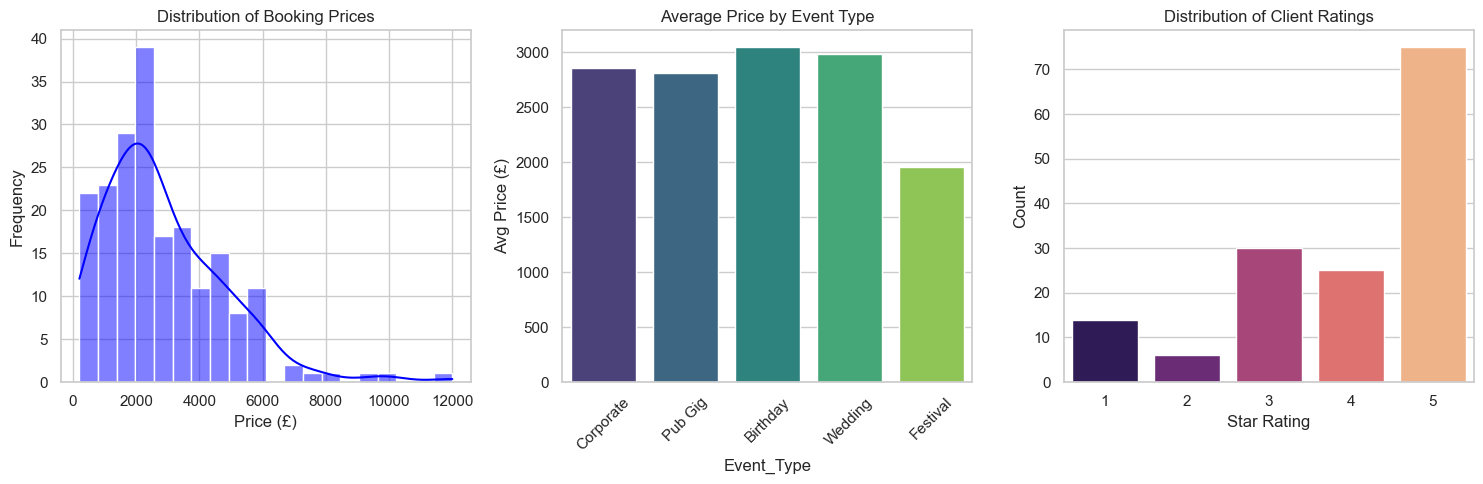

In [4]:
plt.figure(figsize=(15, 5))

# Chart 1: Distribution of Prices Charged
plt.subplot(1, 3, 1)
sns.histplot(master_df['Price_Charged'], bins=20, kde=True, color='blue')
plt.title('Distribution of Booking Prices')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

# Chart 2: Average Price by Event Type
plt.subplot(1, 3, 2)
sns.barplot(data=master_df, x='Event_Type', y='Price_Charged', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Price by Event Type')
plt.xticks(rotation=45)
plt.ylabel('Avg Price (£)')

# Chart 3: Distribution of Review Ratings
plt.subplot(1, 3, 3)
sns.countplot(data=reviews_df, x='Rating', palette='magma')
plt.title('Distribution of Client Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Download the VADER lexicon if you haven't already
nltk.download('vader_lexicon')

# Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to the Review_Text column
reviews_df['VADER_Scores'] = reviews_df['Review_Text'].apply(lambda x: sia.polarity_scores(str(x)))

# Extract the compound score (ranges from -1 to 1)
reviews_df['VADER_Compound'] = reviews_df['VADER_Scores'].apply(lambda d: d['compound'])

# Classify based on the compound score
reviews_df['VADER_Label'] = reviews_df['VADER_Compound'].apply(
    lambda score: 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
)

print(reviews_df[['Review_Text', 'VADER_Compound', 'VADER_Label']].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\damik\AppData\Roaming\nltk_data...


                                         Review_Text  VADER_Compound  \
0  Absolutely amazing! Very punctual and the soun...          0.8436   
1  Great crowd engagement. They really knew how t...          0.8750   
2  Top notch performance. Punctual and profession...          0.2023   
3  The sound quality blew us away. Incredible att...          0.5413   
4  Amazing crowd engagement. Everyone was on the ...          0.7783   

  VADER_Label  
0    Positive  
1    Positive  
2    Positive  
3    Positive  
4    Positive  


In [ ]:
pip install torch

In [ ]:
from transformers import pipeline

# Load a pre-trained BERT model for sentiment analysis
# We use a lightweight version (DistilBERT) to save compute time, but it functions the same way
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_bert_sentiment(text):
    try:
        # Truncate text to 512 tokens to avoid BERT crashing on long reviews
        result = sentiment_pipeline(str(text)[:512])[0]
        # Convert label and score to a normalized metric (-1 to 1)
        score = result['score'] if result['label'] == 'POSITIVE' else -result['score']
        label = 'Positive' if result['label'] == 'POSITIVE' else 'Negative'
        return pd.Series([score, label])
    except Exception as e:
        return pd.Series([0.0, 'Neutral'])

# Apply the BERT model
reviews_df[['BERT_Score', 'BERT_Label']] = reviews_df['Review_Text'].apply(get_bert_sentiment)

print(reviews_df[['Review_Text', 'VADER_Label', 'BERT_Label']].head())

c:\Users\damik\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
c:\Users\damik\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\damik\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disab

NameError: name 'torch' is not defined